In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax.core import unfreeze, freeze

from pyscf import gto, scf, ao2mo, cc

import importlib

import wavefunctions, hamiltonian, trajectory, qc

import time

/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


50 89
0.04111698144358104
(89, 28) (89, 28)


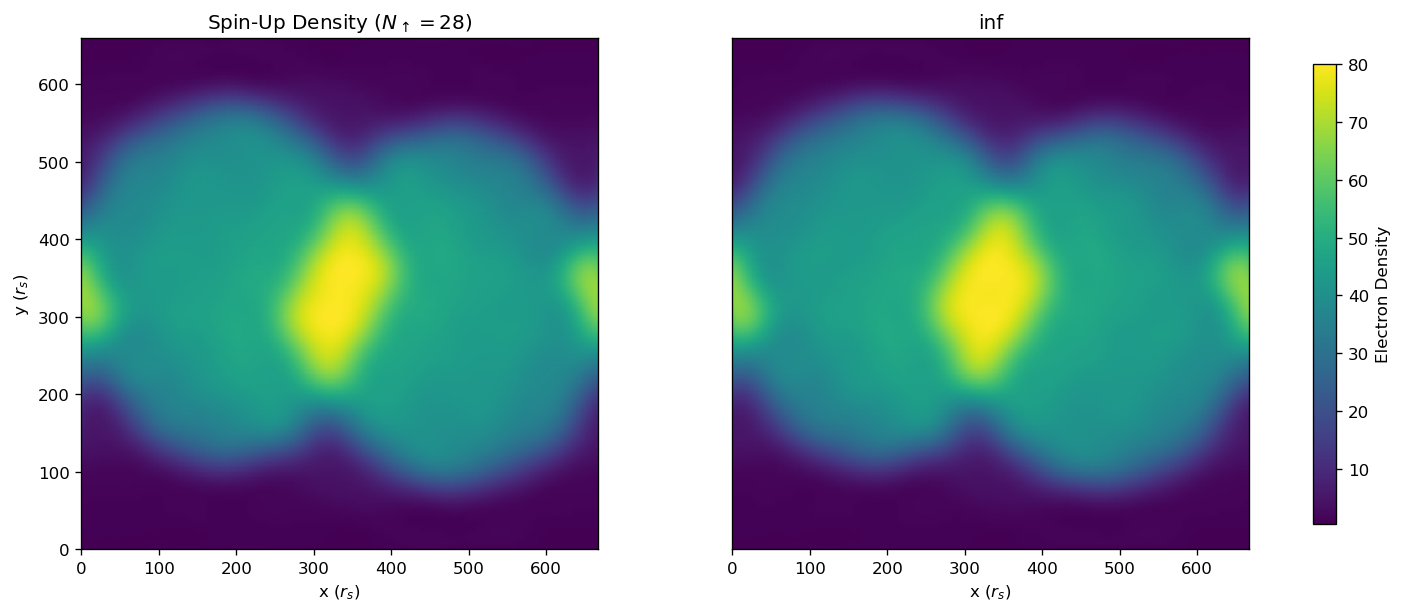

----------------------
-0.016140830286395357
(89, 28) (89, 28)


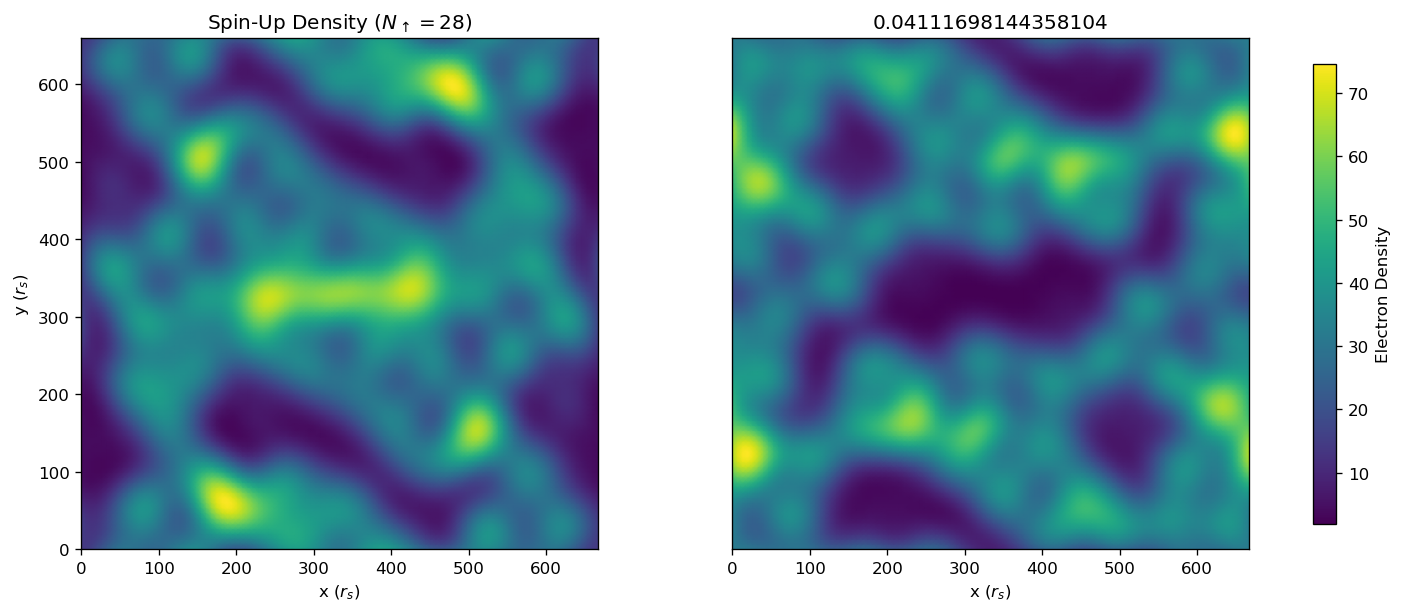

----------------------
0.04007538362038021
(89, 28) (89, 28)


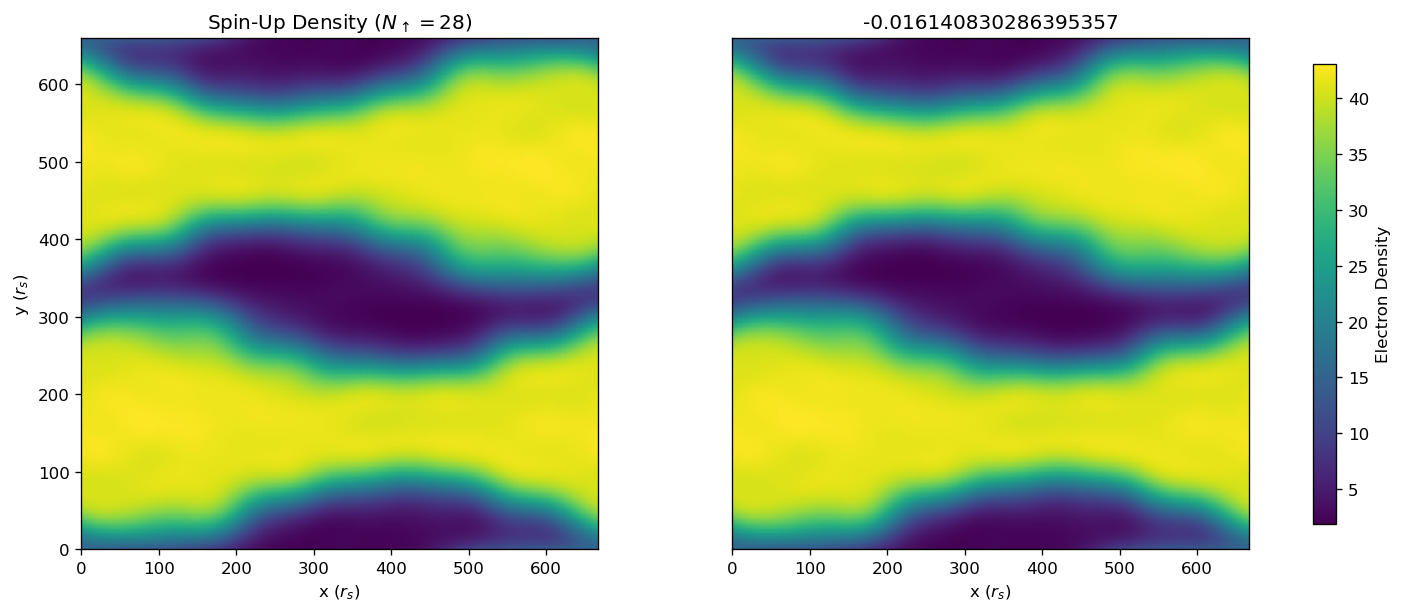

----------------------
-0.016127811709095156
(89, 28) (89, 28)


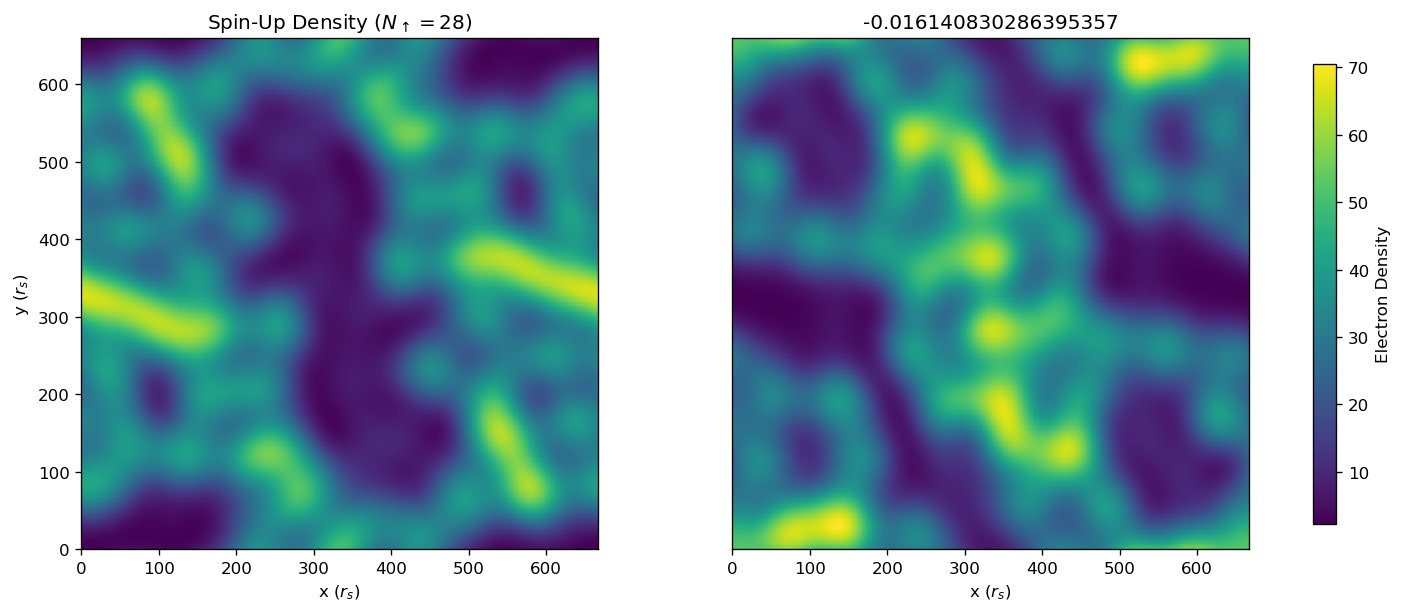

----------------------
-0.01600389097601707
(89, 28) (89, 28)


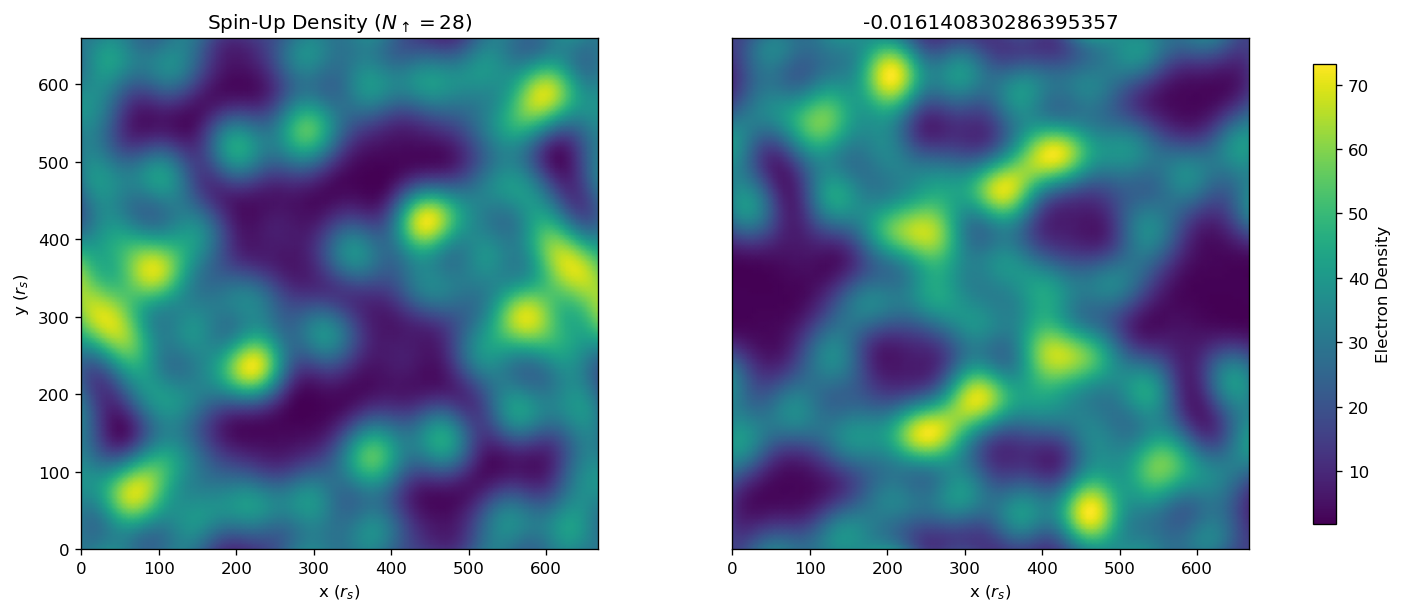

----------------------
UHF:     	-0.016140830286395357



In [31]:
importlib.reload(wavefunctions)
importlib.reload(hamiltonian)

spins = (28,28)
dim = 2

N = spins[0] + spins[1]

r_ws = 50

# Flatiron's rectangular lattice
lattice = wavefunctions.computeLattice(
    N, r_ws, dim,
    basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)

system = qc.ueg_qc(0, spins, dim=dim, e_cut_red=3.0/(r_ws**2), basis=lattice)
k_points = system.get_k_points()
n_kpts = k_points.shape[0]
print(r_ws, n_kpts)
h1 = system.get_h1(k_points)
eri_jax = system.get_eri_tensor_real(k_points)
eri = np.asarray(eri_jax, dtype=np.double)

mol = gto.M(verbose=0)
mol.nelectron = system.n_particles
mol.incore_anyway = True
mol.energy_nuc = lambda *args: 0.0
mol.verbose = 0

uhf_energy = np.inf
best_umf = None

umf = scf.UHF(mol)
umf.max_cycle = 200
umf.get_hcore = lambda *args: [h1, h1]
umf.get_ovlp = lambda *args: np.eye(n_kpts)
umf._eri = ao2mo.restore(8, eri, n_kpts)
umf.init_guess = "1e"
start = time.time()
for seed in range(5):
    
    np.random.seed(seed)
    dm0 = umf.get_init_guess()
    dm0[0] += np.random.randn(n_kpts, n_kpts) * 0.1
    dm0[1] += np.random.randn(n_kpts, n_kpts) * 0.1
    escf = umf.kernel(dm0)
    mo1 = umf.stability()[0]
    
    upCoeffs = umf.mo_coeff[0][:,:spins[0]]
    downCoeffs = umf.mo_coeff[1][:,:spins[1]]
    
    print(escf / N)
    print(upCoeffs.shape, downCoeffs.shape)
    
    def eval_basis_at_point(r):
        dot_vals = jnp.dot(k_points, r)
        terms = jnp.exp(1j * dot_vals)
        return terms
    
    # 3. Generate Grid
    n_grid = 100
    u = jnp.linspace(0, 1, n_grid)
    v = jnp.linspace(0, 1, n_grid)
    uu, vv = jnp.meshgrid(u, v) 
    flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
    flat_real = flat_frac @ lattice 
    
    # 4. Compute Densities
    # Evaluate basis: (N_grid, N_k)
    basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 
    
    # Calculate Up Orbitals: (N_grid, N_k) @ (N_k, N_up) -> (N_grid, N_up)
    orbitals_up = jnp.dot(basis_vals, upCoeffs)
    # Calculate Down Orbitals: (N_grid, N_k) @ (N_k, N_down) -> (N_grid, N_down)
    orbitals_down = jnp.dot(basis_vals, downCoeffs)
    
    # Sum squares to get density
    rho_up = jnp.sum(np.abs(orbitals_up)**2, axis=1).reshape(n_grid, n_grid)
    rho_down = jnp.sum(np.abs(orbitals_down)**2, axis=1).reshape(n_grid, n_grid)
    
    # 5. Plot Side-by-Side
    # Grid coordinates for plotting
    grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
    X_plot = grid_real[:, :, 0]
    Y_plot = grid_real[:, :, 1]
    
    # Determine global min/max for shared colorbar
    vmin = min(rho_up.min(), rho_down.min())
    vmax = max(rho_up.max(), rho_down.max())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)
    
    # Plot Up
    im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Spin-Up Density ($N_{{\\uparrow}}={spins[0]}$)")
    axes[0].set_aspect('equal')
    axes[0].set_xlabel("x ($r_s$)")
    axes[0].set_ylabel("y ($r_s$)")
    
    # Plot Down
    im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Spin-Down Density ($N_{{\\downarrow}}={spins[1]}$)")
    axes[1].set_aspect('equal')
    axes[1].set_xlabel("x ($r_s$)")
    axes[1].set_yticks([]) # Hide Y ticks for the second plot
    
    # Shared Colorbar
    fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)
    plt.title(uhf_energy / N)
    plt.show()
    
    if uhf_energy is np.inf or escf < uhf_energy:
        uhf_energy = escf
        bestUpCoeffs = umf.mo_coeff[0][:,:spins[0]]
        bestDownCoeffs = umf.mo_coeff[1][:,:spins[1]]
        best_umf = umf

    print("----------------------")

print(f"UHF:     \t{uhf_energy / N}")
print()

(89, 28) (89, 28)


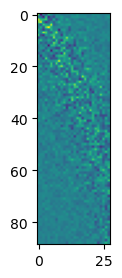

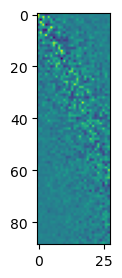

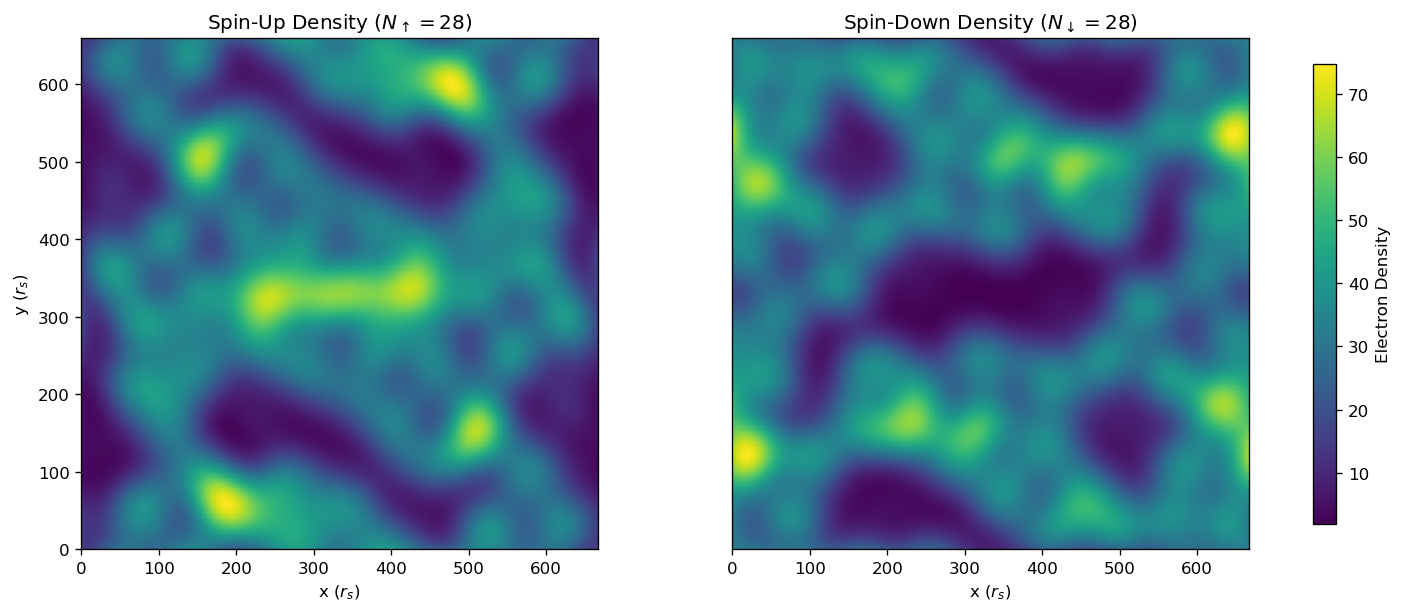

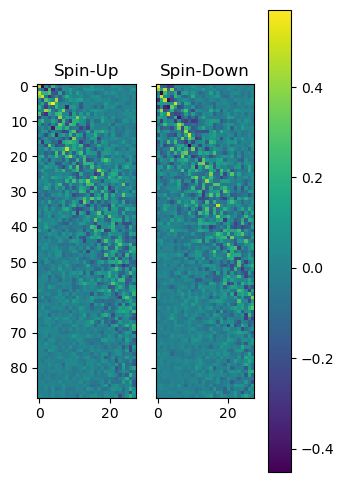

In [29]:
print(upCoeffs.shape, downCoeffs.shape)

plt.figure(figsize=(4,3))
plt.imshow(upCoeffs)
plt.show()

plt.figure(figsize=(4,3))
plt.imshow(downCoeffs)
plt.show()

def eval_basis_at_point(r):
    dot_vals = jnp.dot(k_points, r)
    terms = jnp.exp(1j * dot_vals)
    return terms

# 3. Generate Grid
n_grid = 100
u = jnp.linspace(0, 1, n_grid)
v = jnp.linspace(0, 1, n_grid)
uu, vv = jnp.meshgrid(u, v) 
flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
flat_real = flat_frac @ lattice 

# 4. Compute Densities
# Evaluate basis: (N_grid, N_k)
basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 

# Calculate Up Orbitals: (N_grid, N_k) @ (N_k, N_up) -> (N_grid, N_up)
orbitals_up = jnp.dot(basis_vals, upCoeffs)
# Calculate Down Orbitals: (N_grid, N_k) @ (N_k, N_down) -> (N_grid, N_down)
orbitals_down = jnp.dot(basis_vals, downCoeffs)

# Sum squares to get density
rho_up = jnp.sum(np.abs(orbitals_up)**2, axis=1).reshape(n_grid, n_grid)
rho_down = jnp.sum(np.abs(orbitals_down)**2, axis=1).reshape(n_grid, n_grid)

# 5. Plot Side-by-Side
# Grid coordinates for plotting
grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
X_plot = grid_real[:, :, 0]
Y_plot = grid_real[:, :, 1]

# Determine global min/max for shared colorbar
vmin = min(rho_up.min(), rho_down.min())
vmax = max(rho_up.max(), rho_down.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)

# Plot Up
im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f"Spin-Up Density ($N_{{\\uparrow}}={spins[0]}$)")
axes[0].set_aspect('equal')
axes[0].set_xlabel("x ($r_s$)")
axes[0].set_ylabel("y ($r_s$)")

# Plot Down
im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f"Spin-Down Density ($N_{{\\downarrow}}={spins[1]}$)")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x ($r_s$)")
axes[1].set_yticks([]) # Hide Y ticks for the second plot

# Shared Colorbar
fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)

plt.show()

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3.5,6), sharey=True)
im0 = axs[0].imshow(upCoeffs)
axs[0].set_title("Spin-Up")
im1 = axs[1].imshow(downCoeffs)
axs[1].set_title("Spin-Down")
fig.colorbar(im1, ax=axs)
plt.show()

In [2]:
importlib.reload(wavefunctions)
importlib.reload(hamiltonian)

spins = (28,28)
dim = 2

N = spins[0] + spins[1]

r_ws = 50

for r_ws in [10, 20, 25, 30, 35, 40, 45, 50]:

    # Flatiron's rectangular lattice
    lattice = wavefunctions.computeLattice(
        N, r_ws, dim,
        basis_matrix=jnp.eye(dim) + 0.2
    )

    system = qc.ueg_qc(0, spins, dim=dim, e_cut_red=3.0/(r_ws**2), basis=lattice)
    k_points = system.get_k_points()
    n_kpts = k_points.shape[0]
    print(r_ws, n_kpts)
    h1 = system.get_h1(k_points)
    eri_jax = system.get_eri_tensor_real(k_points)
    eri = np.asarray(eri_jax, dtype=np.double)

    mol = gto.M(verbose=0)
    mol.nelectron = system.n_particles
    mol.incore_anyway = True
    mol.energy_nuc = lambda *args: 0.0
    mol.verbose = 0

    uhf_energy = np.inf
    best_umf = None

    umf = scf.UHF(mol)
    umf.max_cycle = 200
    umf.get_hcore = lambda *args: [h1, h1]
    umf.get_ovlp = lambda *args: np.eye(n_kpts)
    umf._eri = ao2mo.restore(8, eri, n_kpts)
    # umf.init_guess = "1e"
    start = time.time()
    for seed in range(5):
        np.random.seed(seed)
        dm0 = umf.get_init_guess()
        dm0[0] += np.random.randn(n_kpts, n_kpts) * 0.1
        dm0[1] += np.random.randn(n_kpts, n_kpts) * 0.1
        escf = umf.kernel(dm0)
        mo1 = umf.stability()[0]
        print(escf / N)
        if uhf_energy is np.inf or escf < uhf_energy:
            uhf_energy = escf
            best_umf = umf

    print(f"UHF:     \t{uhf_energy / N}")
    print()

10 91


/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/pyscf/gto/mole.py:1293: UserWarning: Function mol.dumps drops attribute energy_nuc because it is not JSON-serializable
  warnings.warn(msg)


-0.07206968751158513
-0.07201580338269631
-0.07243661777109468
-0.07259413526340644
0.21410640110854565
UHF:     	-0.07259413526340644

20 91
-0.03875771616325303
-0.039009972268018125
-0.038939896311364235
0.10808463251180621
0.10838888254208527
UHF:     	-0.039009972268018125

25 91
-0.03144993215954807
-0.031724093862380405
-0.031756648021264704
0.07870251276168302
0.08607414994153992
UHF:     	-0.031756648021264704

30 91
-0.026509852782994812
-0.02643160265743218
-0.0266328946732947
0.06831628906005051
0.0711204042345624
UHF:     	-0.0266328946732947

35 91
-0.02276687494903695
-0.022799832161987416
-0.022934200523112735
0.058830328647338746
-0.022693946571818707
UHF:     	-0.022934200523112735

40 91
-0.020038764077360605
-0.02011773081831452
-0.020239230206931517
0.002484312494893432
-0.020106204943390604
UHF:     	-0.020239230206931517

45 91
-0.017964510476892348
0.04748169989352961
-0.018002048538308255
0.04696355618492016
0.047489984577146545
UHF:     	-0.018002048538308255
